# ✈️ Flight Delay Dataset — 2024 (Starter Notebook)

This notebook provides a quick introduction to the **Flight Delay Dataset — 2024**, which contains over **7 million rows** of flight performance and delay records for U.S. domestic flights in 2024.

The dataset is suitable for:
- Exploratory Data Analysis (EDA)
- Flight delay prediction with Machine Learning
- Time series and trend analysis
- Airline/airport performance comparisons

---

## 📂 Dataset Files
- **`flight_data_2024.csv`** — full dataset (7M+ rows, 35 columns)  
- **`flight_data_2024_sample.csv`** — sample of 10,000 rows  
- **`flight_data_2024_data_dictionary.csv`** — column descriptions and metadata  

---

## 🚀 Notebook Goals
In this starter notebook, we will:
1. Load the dataset and preview its structure  
2. Explore summary statistics  
3. Analyze **average delays by month**  
4. Identify **busiest airports**  
5. Visualize **cancellation reasons**

This notebook is a starting point — feel free to extend it with more advanced analysis, visualizations, or predictive modeling.

---


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/flight-data-2024/flight_data_2024.csv", low_memory=False)

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (7079081, 35)


In [4]:
display(df.head())

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [5]:
display(df.describe(include="all").transpose().head(10))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,7079081.0,NaN,NaN,NaN,2024.0,0.0,2024.0,2024.0,2024.0,2024.0,2024.0
month,7079081.0,NaN,NaN,NaN,6.584868,3.396806,1.0,4.0,7.0,10.0,12.0
day_of_month,7079081.0,NaN,NaN,NaN,15.784451,8.786433,1.0,8.0,16.0,23.0,31.0
day_of_week,7079081.0,NaN,NaN,NaN,3.981945,2.012279,1.0,2.0,4.0,6.0,7.0
fl_date,7079081,366,2024-12-01,21764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_unique_carrier,7079081,15,WN,1419419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_carrier_fl_num,7079080.0,NaN,NaN,NaN,2504.622501,1652.252505,1.0,1151.0,2227.0,3717.0,8819.0
origin,7079081,348,ATL,341910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_city_name,7079081,342,"Chicago, IL",359685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_state_nm,7079081,52,Texas,751839,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
### 1. Average delay statistics
---

In [6]:
print("Average Departure Delay (minutes):", df["dep_delay"].mean())

Average Departure Delay (minutes): 12.67708199884027


In [7]:
print("Average Arrival Delay (minutes):", df["arr_delay"].mean())

Average Arrival Delay (minutes): 7.09824533646736


---
### 2. Delays by Month
---

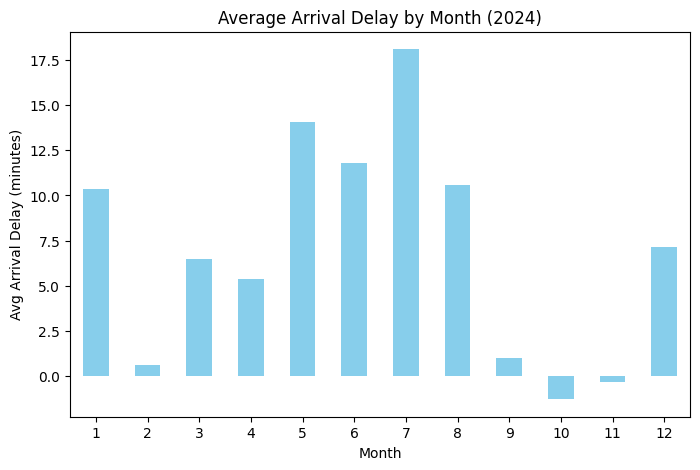

In [8]:
monthly_delay = df.groupby("month")["arr_delay"].mean()

plt.figure(figsize=(8,5))
monthly_delay.plot(kind="bar", color="skyblue")
plt.title("Average Arrival Delay by Month (2024)")
plt.xlabel("Month")
plt.ylabel("Avg Arrival Delay (minutes)")
plt.xticks(rotation=0)
plt.show()

---
### 3. Top 10 busiest origin airports
---

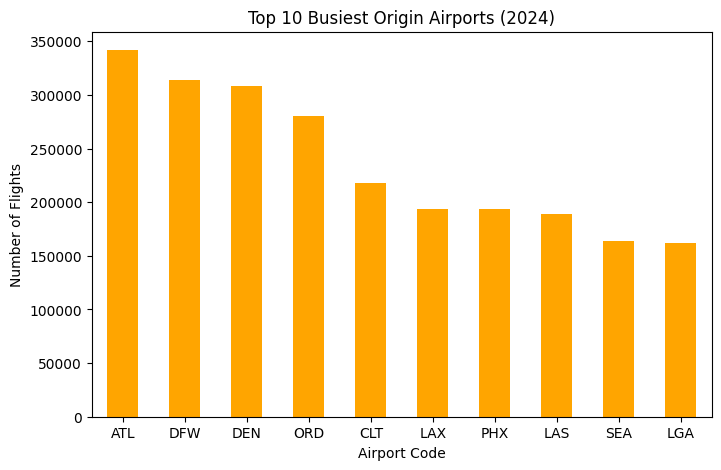

In [9]:
busiest_airports = df["origin"].value_counts().head(10)

plt.figure(figsize=(8,5))
busiest_airports.plot(kind="bar", color="orange")
plt.title("Top 10 Busiest Origin Airports (2024)")
plt.xlabel("Airport Code")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.show()

---
### 4. Flight cancellation reasons
---

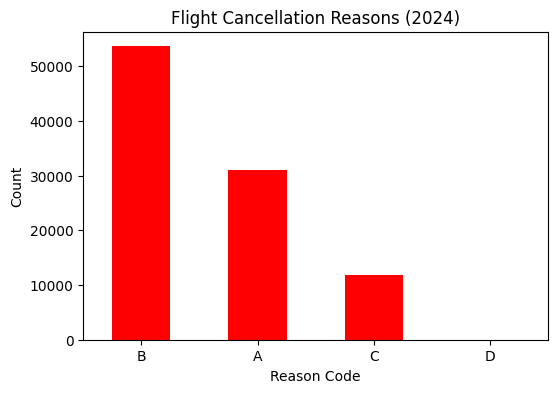

In [10]:
cancel_reasons = df["cancellation_code"].value_counts()

plt.figure(figsize=(6,4))
cancel_reasons.plot(kind="bar", color="red")
plt.title("Flight Cancellation Reasons (2024)")
plt.xlabel("Reason Code")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()